# 01.1 HVG Investigation

This notebook investigates Highly Variable Gene (HVG) selection in the cross-species
(human-mouse) optimal transport pipeline. The workflow is:

1. Load Tabula Sapiens (human) and Tabula Muris (mouse) data, split by donor
2. Match cells across species by shared (cell type, tissue) pairs
3. Align gene spaces via BioMart one-to-one orthologs
4. Select HVGs on training data (holding out one cell type)
5. Inspect top/bottom HVGs and check where PTPRC falls in the ranking
6. Compare UMAPs: 14k ortholog space (with PTPRC) vs 1000-HVG space
7. Quantify HVG quality via silhouette scores

In [1]:
import sys
sys.path.insert(0, "/n/holylabs/mooney_lab/Lab/junyizhou/speciesOT/speciesOT")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import anndata as ad
import scanpy as sc

from speciesot_helpers import (
    top_n_organisms_from_species,
    match_cells_by_celltype_tissue,
    align_adatas_biomart_one2one,
)

/n/holylabs/mooney_lab/Lab/joshprice/speciesOT/speciesOT_env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Load data and combine donors

In [2]:
human_dir = '/n/holylabs/mooney_lab/Lab/joshprice/speciesOT/data/tabula_sapiens/'
mouse_dir = '/n/holylabs/mooney_lab/Lab/joshprice/speciesOT/data/tabula_muris/'

human_adatas = top_n_organisms_from_species(human_dir, -1, 'human')
mouse_adatas = top_n_organisms_from_species(mouse_dir, -1, 'mouse')

human_combined = ad.concat(human_adatas, join="outer")
mouse_combined = ad.concat(mouse_adatas, join="outer")

print(f"Human: {len(human_adatas)} donors, {human_combined.shape[0]} cells, {human_combined.shape[1]} genes")
print(f"Mouse: {len(mouse_adatas)} donors, {mouse_combined.shape[0]} cells, {mouse_combined.shape[1]} genes")

Human: 24 donors, 58931 cells, 61759 genes
Mouse: 40 donors, 47807 cells, 18024 genes


In [3]:
print(human_combined)
print(mouse_combined)

AnnData object with n_obs × n_vars = 58931 × 61759
    obs: 'donor_id', 'tissue_in_publication', 'anatomical_position', 'method', 'cdna_plate', 'library_plate', 'notes', 'cdna_well', 'assay_ontology_term_id', 'sample_id', 'replicate', '10X_run', 'ambient_removal', 'donor_method', 'donor_assay', 'donor_tissue', 'donor_tissue_assay', 'cell_type_ontology_term_id', 'compartment', 'broad_cell_class', 'free_annotation', 'manually_annotated', 'published_2022', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_ercc', 'pct_counts_ercc', '_scvi_batch', '_scvi_labels', 'scvi_leiden_donorassay_full', 'ethnicity_original', 'scvi_leiden_res05_compartment', 'sample_number', 'suspension_type', 'tissue_type', 'disease_ontology_term_id', 'is_primary_data', 'tissue_ontology_term_id', 'sex_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'development_stage_ontology_term_id', 'cell_type', 'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicity', 'dev

## 2. Match cells by (cell type, tissue) across species

Creates a composite key `cell_type_ontology_term_id | tissue_ontology_term_id` for
each cell and retains only the (cell type, tissue) combinations present in **both**
species, with equal cell counts per combination.

In [4]:
mouse_matched, human_matched = match_cells_by_celltype_tissue(mouse_combined, human_combined)

print(f"Matched mouse: {mouse_matched.shape}")
print(f"Matched human: {human_matched.shape}")

Matched mouse: (6495, 18024)
Matched human: (6495, 61759)


## 3. Gene space alignment via BioMart one-to-one orthologs

`align_adatas_biomart_one2one` queries Ensembl BioMart for mouse-human one-to-one
ortholog pairs, then subsets both AnnData objects to those shared genes so that
column *i* in the mouse output is the ortholog of column *i* in the human output.
Typically yields ~14k-17k shared genes for Tabula Sapiens x Tabula Muris.

In [5]:
print(f"Pre-alignment genes  -- Mouse: {mouse_matched.n_vars}  Human: {human_matched.n_vars}")

mouse_shared, human_shared, ortholog_table = align_adatas_biomart_one2one(
    mouse_matched, human_matched
)

print(f"Ortholog pairs kept: {len(ortholog_table)}")
print(f"Post-alignment      -- Mouse: {mouse_shared.shape}  Human: {human_shared.shape}")
assert list(mouse_shared.var_names) == list(human_shared.var_names)

Pre-alignment genes  -- Mouse: 18024  Human: 61759
Ortholog pairs kept: 14451
Post-alignment      -- Mouse: (6495, 14451)  Human: (6495, 14451)


In [6]:
# obsm stands for observation matrices
# there are 7 of them
print(human_shared)
for k, v in human_shared.obsm.items():
    print(f"  {k:42s} shape={v.shape}")
# layers are alternate expression matrices but strictly the same shape as X
for k, v in human_shared.layers.items():
    print(f"{k}: {v.shape}")


# obsm stands for observation matrices
# there are 7 of them
print(mouse_shared)
for k, v in mouse_shared.obsm.items():
    print(f"  {k:42s} shape={v.shape}")
# layers are alternate expression matrices but strictly the same shape as X
for k, v in mouse_shared.layers.items():
    print(f"{k}: {v.shape}")

AnnData object with n_obs × n_vars = 6495 × 14451
    obs: 'donor_id', 'tissue_in_publication', 'anatomical_position', 'method', 'cdna_plate', 'library_plate', 'notes', 'cdna_well', 'assay_ontology_term_id', 'sample_id', 'replicate', '10X_run', 'ambient_removal', 'donor_method', 'donor_assay', 'donor_tissue', 'donor_tissue_assay', 'cell_type_ontology_term_id', 'compartment', 'broad_cell_class', 'free_annotation', 'manually_annotated', 'published_2022', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_ercc', 'pct_counts_ercc', '_scvi_batch', '_scvi_labels', 'scvi_leiden_donorassay_full', 'ethnicity_original', 'scvi_leiden_res05_compartment', 'sample_number', 'suspension_type', 'tissue_type', 'disease_ontology_term_id', 'is_primary_data', 'tissue_ontology_term_id', 'sex_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'development_stage_ontology_term_id', 'cell_type', 'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicity', 'deve

In [7]:
# Checking if ENSG00000081237 is present in both mouse and human
print(f"ENSG00000081237 present in mouse: {"ENSG00000081237" in mouse_shared.var_names}")
print(f"ENSG00000081237 present in human: {"ENSG00000081237" in human_shared.var_names}")


ENSG00000081237 present in mouse: True
ENSG00000081237 present in human: True


## 4. HVG selection on training data (holdout: T cells)

Hold out one cell type (`CL:0000084` = T cell), concatenate the remaining mouse +
human training cells, and select the top 1000 HVGs by Seurat-style dispersion.

In [8]:
def prepare_training_data(
    mouse_adata,
    human_adata,
    holdout_celltype_id=None,
    n_hvg=1000,
):
    """
    Split matched mouse/human AnnData into train and holdout by
    cell_type_ontology_term_id, then select HVGs from training data only.

    Both input AnnData objects must share the same var_names (gene-aligned).

    Returns
    -------
    train_mouse, train_human : AnnData  (HVG-subset training cells)
    hold_mouse,  hold_human  : AnnData or None
    hvg_genes                : list[str]
    """
    m = mouse_adata.copy()
    h = human_adata.copy()

    if holdout_celltype_id is not None:
        m_mask = m.obs['cell_type_ontology_term_id'].astype(str) != holdout_celltype_id
        h_mask = h.obs['cell_type_ontology_term_id'].astype(str) != holdout_celltype_id
        m_train, m_hold = m[m_mask].copy(), m[~m_mask].copy()
        h_train, h_hold = h[h_mask].copy(), h[~h_mask].copy()
    else:
        m_train, h_train = m.copy(), h.copy()
        m_hold = h_hold = None

    print(f"Training cells:  mouse={m_train.n_obs}  human={h_train.n_obs}  "
          f"total={m_train.n_obs + h_train.n_obs}")
    if m_hold is not None:
        print(f"Holdout cells:   mouse={m_hold.n_obs}  human={h_hold.n_obs}  "
              f"total={m_hold.n_obs + h_hold.n_obs}")

    combined = ad.concat([m_train, h_train], join='inner')
    sc.pp.highly_variable_genes(combined, n_top_genes=n_hvg, flavor='seurat')
    hvg_genes = combined.var_names[combined.var.highly_variable].tolist()
    print(f"Selected {len(hvg_genes)} HVGs from training data")

    m_train = m_train[:, hvg_genes].copy()
    h_train = h_train[:, hvg_genes].copy()
    if m_hold is not None:
        m_hold = m_hold[:, hvg_genes].copy()
        h_hold = h_hold[:, hvg_genes].copy()

    print(f"Final train shapes:  mouse={m_train.shape}  human={h_train.shape}")
    if m_hold is not None:
        print(f"Final holdout shapes: mouse={m_hold.shape}  human={h_hold.shape}")

    return m_train, h_train, m_hold, h_hold, hvg_genes

In [9]:
HOLDOUT_CELLTYPE = "CL:0000084"  # T cell

print(f"Holdout cell type: {HOLDOUT_CELLTYPE}")
print("=" * 60)
train_m, train_h, hold_m, hold_h, hvgs = prepare_training_data(
    mouse_shared, human_shared,
    holdout_celltype_id=HOLDOUT_CELLTYPE,
    n_hvg=1000,
)
print(f"\nFirst 10 HVGs: {hvgs[:10]}")

Holdout cell type: CL:0000084
Training cells:  mouse=6393  human=6393  total=12786
Holdout cells:   mouse=102  human=102  total=204
Selected 1000 HVGs from training data
Final train shapes:  mouse=(6393, 1000)  human=(6393, 1000)
Final holdout shapes: mouse=(102, 1000)  human=(102, 1000)

First 10 HVGs: ['ENSG00000114374', 'ENSG00000156282', 'ENSG00000188694', 'ENSG00000160181', 'ENSG00000160182', 'ENSG00000184221', 'ENSG00000182591', 'ENSG00000150893', 'ENSG00000186970', 'ENSG00000182968']


In [28]:
# Checking if ENSG00000081237 is present in both mouse and human
print(f"ENSG00000081237 present in mouse: {"ENSG00000081237" in train_m.var_names}")
print(f"ENSG00000081237 present in human: {"ENSG00000081237" in train_h.var_names}")


ENSG00000081237 present in mouse: False
ENSG00000081237 present in human: False


## 5. Inspect HVG dispersion statistics

In [10]:
# Called mask becaue it produced a boolean array
m_mask = mouse_shared.obs['cell_type_ontology_term_id'].astype(str) != HOLDOUT_CELLTYPE
h_mask = human_shared.obs['cell_type_ontology_term_id'].astype(str) != HOLDOUT_CELLTYPE

# inner join because we want to keep all the genes that are present in both species
# but mouse_shared and human_shared are already aligned by biomart
train_combined_full = ad.concat(
    [mouse_shared[m_mask].copy(), human_shared[h_mask].copy()], join='inner'
)

# ad.concat drops the layers as well as the var
# obsm also drops from 7 to 2
print(train_combined_full)
print(human_shared)
print(human_shared[h_mask])

AnnData object with n_obs × n_vars = 12786 × 14451
    obs: 'free_annotation', 'method', 'donor_id', 'assay_ontology_term_id', 'disease_ontology_term_id', 'cell_type_ontology_term_id', 'tissue_ontology_term_id', 'development_stage_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'sex_ontology_term_id', 'is_primary_data', 'suspension_type', 'tissue_type', 'cell_type', 'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid', 'shared_cell_type'
    obsm: 'X_pca', 'X_umap'
AnnData object with n_obs × n_vars = 6495 × 14451
    obs: 'donor_id', 'tissue_in_publication', 'anatomical_position', 'method', 'cdna_plate', 'library_plate', 'notes', 'cdna_well', 'assay_ontology_term_id', 'sample_id', 'replicate', '10X_run', 'ambient_removal', 'donor_method', 'donor_assay', 'donor_tissue', 'donor_tissue_assay', 'cell_type_ontology_term_id', 'compartment', 'broad_cell_class', 'free_annotation', 'manually_annotated', 'published_2022', 'n_ge

In [11]:
# scanpy.pp.highly_variable_genes expects logarithmized data when flavor="seurat"
print(train_combined_full.X.min())
print(train_combined_full.X.max())

0.0
10.0


In [12]:
print(mouse_shared)
print(mouse_shared.X)

AnnData object with n_obs × n_vars = 6495 × 14451
    obs: 'batch', 'tissue_FACS_droplet', 'free_annotation', 'n_counts', 'n_genes', 'louvain', 'leiden', 'age', 'method', 'donor_id', 'subtissue', 'tissue_free_annotation', 'assay_ontology_term_id', 'disease_ontology_term_id', 'cell_type_ontology_term_id', 'tissue_ontology_term_id', 'development_stage_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'sex_ontology_term_id', 'is_primary_data', 'suspension_type', 'FACS.selection', 'tissue_original', 'tissue_type', 'cell_type', 'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid', 'shared_cell_type'
    var: 'human_ensembl_id', 'mouse_ensembl_id'
    obsm: 'X_pca', 'X_umap'
<Compressed Sparse Row sparse matrix of dtype 'float32'
	with 13102990 stored elements and shape (6495, 14451)>
  Coords	Values
  (0, 9021)	2.5604779720306396
  (0, 5459)	2.7248902320861816
  (0, 7496)	3.239853620529175
  (0, 13057)	2.9636693000793457
  (0

In [13]:
# Witness the staircase values
# These are not random looking floats
print(human_shared)
print(human_shared.X)

AnnData object with n_obs × n_vars = 6495 × 14451
    obs: 'donor_id', 'tissue_in_publication', 'anatomical_position', 'method', 'cdna_plate', 'library_plate', 'notes', 'cdna_well', 'assay_ontology_term_id', 'sample_id', 'replicate', '10X_run', 'ambient_removal', 'donor_method', 'donor_assay', 'donor_tissue', 'donor_tissue_assay', 'cell_type_ontology_term_id', 'compartment', 'broad_cell_class', 'free_annotation', 'manually_annotated', 'published_2022', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_ercc', 'pct_counts_ercc', '_scvi_batch', '_scvi_labels', 'scvi_leiden_donorassay_full', 'ethnicity_original', 'scvi_leiden_res05_compartment', 'sample_number', 'suspension_type', 'tissue_type', 'disease_ontology_term_id', 'is_primary_data', 'tissue_ontology_term_id', 'sex_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'development_stage_ontology_term_id', 'cell_type', 'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicity', 'deve

In [14]:
# Human shared scale checking
import numpy as np
from scipy import sparse

X = human_shared.X
if sparse.issparse(X):
    print("sparse, dtype:", X.dtype, " nnz:", X.nnz)
    nz = X.data
else:
    print("dense, dtype:", X.dtype)
    nz = X[X > 0]

print(f"min={X.min():.4f}  max={X.max():.4f}  mean={X.mean():.4f}")
print(f"# unique non-zero values: {np.unique(nz).size}")
print(f"first 10 sorted unique non-zeros: {np.sort(np.unique(nz))[:10]}")
print(f"uns keys: {list(train_combined_full.uns.keys())}")
print(f"log1p in uns? {'log1p' in train_combined_full.uns}")

sparse, dtype: float32  nnz: 16935616
min=0.0000  max=8.5077  mean=0.1800
# unique non-zero values: 672062
first 10 sorted unique non-zeros: [0.00090098 0.00094598 0.00098245 0.00098853 0.00113425 0.00117296
 0.00117711 0.00117779 0.00118734 0.00118886]
uns keys: []
log1p in uns? False


In [15]:
# Checking if mouse data is log1p transformed
import numpy as np
from scipy import sparse

X = mouse_shared.X
if sparse.issparse(X):
    print("sparse, dtype:", X.dtype, " nnz:", X.nnz)
    nz = X.data
else:
    print("dense, dtype:", X.dtype)
    nz = X[X > 0]

print(f"min={X.min():.4f}  max={X.max():.4f}  mean={X.mean():.4f}")
print(f"# unique non-zero values: {np.unique(nz).size}")
print(f"first 10 sorted unique non-zeros: {np.sort(np.unique(nz))[:10]}")
print(f"uns keys: {list(train_combined_full.uns.keys())}")
print(f"log1p in uns? {'log1p' in train_combined_full.uns}")

sparse, dtype: float32  nnz: 13102990
min=0.0000  max=10.0000  mean=0.2937
# unique non-zero values: 10613570
first 10 sorted unique non-zeros: [0.00029964 0.00031837 0.00034013 0.00034221 0.00036165 0.00036258
 0.00040191 0.00041243 0.00041246 0.00049674]
uns keys: []
log1p in uns? False


In [16]:
# At this point, we are aware that the human and mouse data are not aligned
# Human: normalize(total_counts = 10000) and then log1p
# Mouse: normalize(total_counts = 10000) and then log1p and then scale(max_value = 10)
# Not a hundred percent sure about the scale(max_value = 10)
import numpy as np
from scipy import sparse

m_cell = 0
print("obs['n_counts']:", mouse_adatas[0].obs["n_counts"].iloc[m_cell])

row = mouse_adatas[0].X[m_cell]
if sparse.issparse(row):
    row = row.toarray().ravel()
print(f"row sum in .X: {row.sum():.2f}")
print(f"row min non-zero: {row[row > 0].min():.4f}" if (row > 0).any() else "no nonzero")
print(f"row max: {row.max():.4f}")

print("\nTop 5 values and where they are:")
top_idx = np.argsort(row)[-5:]
for i in top_idx:
    print(f"  gene {i}: value={row[i]:.4f}")

obs['n_counts']: 4121.0
row sum in .X: 3532.66
row min non-zero: 0.8399
row max: 10.0000

Top 5 values and where they are:
  gene 15777: value=10.0000
  gene 12303: value=10.0000
  gene 4408: value=10.0000
  gene 823: value=10.0000
  gene 405: value=10.0000


In [17]:
# Realizing we can trace back to the raw data
import scanpy as sc
import anndata as ad

mouse_raw = mouse_shared.raw.to_adata()
human_raw = human_shared.raw.to_adata()

for a in [mouse_raw, human_raw]:
    a.obs = a.obs.copy() if hasattr(a, 'obs') else a.obs

for a in [mouse_raw, human_raw]:
    a.X = a.X.astype("float32")
    sc.pp.normalize_total(a, target_sum=1e4)
    sc.pp.log1p(a)

print("After normalize+log1p:")
for name, a in [("mouse_raw", mouse_raw), ("human_raw", human_raw)]:
    data = a.X.data if hasattr(a.X, "data") else a.X.ravel()
    print(f"  {name}: min={data.min():.4f}  max={data.max():.4f}  "
          f"mean={data.mean():.4f}  unique_nnz={len(set(data[:10000]))}")

After normalize+log1p:
  mouse_raw: min=0.0003  max=8.9909  mean=1.1425  unique_nnz=342
  human_raw: min=0.0009  max=8.9678  mean=0.9435  unique_nnz=168


In [18]:
# Understanding the raw data
import scanpy as sc
import numpy as np
from scipy import sparse

MOUSE_H5AD = "/n/holylabs/mooney_lab/Lab/joshprice/speciesOT/data/tabula_muris/sampled_mouse_shared.h5ad"
HUMAN_H5AD = "/n/holylabs/mooney_lab/Lab/joshprice/speciesOT/data/tabula_sapiens/sampled_human_shared.h5ad"

mouse_fresh = sc.read_h5ad(MOUSE_H5AD)
human_fresh = sc.read_h5ad(HUMAN_H5AD)

print("mouse_fresh .raw?", mouse_fresh.raw is not None)
print("human_fresh .raw?", human_fresh.raw is not None)

for name, a in [("mouse_fresh", mouse_fresh), ("human_fresh", human_fresh)]:
    if a.raw is None:
        print(f"{name}: no .raw")
        continue
    X = a.raw.X
    d = X.data if sparse.issparse(X) else X.ravel()
    sample = d[:1000]
    print(f"\n=== {name}.raw ===")
    print(f"  shape       : {a.raw.shape}")
    print(f"  dtype       : {X.dtype}")
    print(f"  min / max   : {d.min():.2f} / {d.max():.2f}")
    print(f"  all integer : {np.all(sample == sample.astype(int))}")
    print(f"  first 20    : {sample[:20]}")

mouse_fresh .raw? True
human_fresh .raw? True

=== mouse_fresh.raw ===
  shape       : (47807, 18024)
  dtype       : float32
  min / max   : 1.00 / 9523593.00
  all integer : True
  first 20    : [ 16.   2.  34.   9.  19.   2.  13.  20.   2. 397.   4.  51.   2.  13.
  31.   5.  40.  21.  45.  27.]

=== human_fresh.raw ===
  shape       : (58931, 61759)
  dtype       : float32
  min / max   : 1.00 / 5126079.00
  all integer : True
  first 20    : [1. 1. 1. 2. 1. 1. 3. 1. 1. 1. 1. 3. 2. 2. 1. 1. 1. 1. 1. 2.]


In [19]:
# 10x and smartseq2
# Mouse is ~37% Smart-seq2, human is only ~6%

print(mouse_fresh.obs["assay"].value_counts())
print(human_fresh.obs["assay"].value_counts())

assay
10x 3' v2     30326
Smart-seq2    17481
Name: count, dtype: int64
assay
10x 3' v3     51192
10x 5' v2      4297
Smart-seq2     3405
Smart-seq3       37
Name: count, dtype: int64


In [20]:
import scanpy as sc
import anndata as ad
import numpy as np
from scipy import sparse
from speciesot_helpers import (
    align_adatas_biomart_one2one,
    match_cells_by_celltype_tissue,
)

MOUSE_H5AD = "/n/holylabs/mooney_lab/Lab/joshprice/speciesOT/data/tabula_muris/sampled_mouse_shared.h5ad"
HUMAN_H5AD = "/n/holylabs/mooney_lab/Lab/joshprice/speciesOT/data/tabula_sapiens/sampled_human_shared.h5ad"

mouse_full = sc.read_h5ad(MOUSE_H5AD)
human_full = sc.read_h5ad(HUMAN_H5AD)

print("loaded (with .X = log-normalized, .raw = raw counts):")
print(f"  mouse_full: {mouse_full.shape}  .raw: {mouse_full.raw.shape}")
print(f"  human_full: {human_full.shape}  .raw: {human_full.raw.shape}")

mouse = mouse_full.raw.to_adata()
human = human_full.raw.to_adata()

mouse.obs = mouse_full.obs.copy()
human.obs = human_full.obs.copy()

print(f"\nraw-count AnnDatas:")
print(f"  mouse: {mouse.shape}")
print(f"  human: {human.shape}")

mouse_matched, human_matched, match_table = match_cells_by_celltype_tissue(
    mouse,
    human,
    cell_type_key="cell_type_ontology_term_id",
    tissue_key="tissue_ontology_term_id",
    return_match_table=True,
)
print(f"\nafter cell-type + tissue matching:")
print(f"  mouse_matched: {mouse_matched.shape}")
print(f"  human_matched: {human_matched.shape}")
print(f"  {len(match_table)} shared (cell_type, tissue) identities")

mouse_ortho, human_ortho, ortho_table = align_adatas_biomart_one2one(
    mouse_matched, human_matched
)
print(f"\nafter ortholog alignment:")
print(f"  mouse_ortho: {mouse_ortho.shape}")
print(f"  human_ortho: {human_ortho.shape}")
print(f"  {len(ortho_table)} ortholog pairs")

for a in [mouse_ortho, human_ortho]:
    a.X = a.X.astype("float32")
    sc.pp.normalize_total(a, target_sum=1e4)
    sc.pp.log1p(a)

def summary(a, name):
    X = a.X
    d = X.data if sparse.issparse(X) else X.ravel()
    print(f"  {name}: min={d.min():.4f}  max={d.max():.4f}  "
          f"mean={d.mean():.4f}  #unique_nnz_sample={len(np.unique(d[:10000]))}")

print("\nafter normalize+log1p on orthologs:")
summary(mouse_ortho, "mouse_ortho")
summary(human_ortho, "human_ortho")

loaded (with .X = log-normalized, .raw = raw counts):
  mouse_full: (47807, 18024)  .raw: (47807, 18024)
  human_full: (58931, 61759)  .raw: (58931, 61759)

raw-count AnnDatas:
  mouse: (47807, 18024)
  human: (58931, 61759)

after cell-type + tissue matching:
  mouse_matched: (6495, 18024)
  human_matched: (6495, 61759)
  75 shared (cell_type, tissue) identities

after ortholog alignment:
  mouse_ortho: (6495, 14451)
  human_ortho: (6495, 14451)
  14451 ortholog pairs

after normalize+log1p on orthologs:
  mouse_ortho: min=0.0003  max=8.8695  mean=1.2429  #unique_nnz_sample=265
  human_ortho: min=0.0013  max=8.8025  mean=1.1957  #unique_nnz_sample=147


In [21]:
print(mouse_ortho)
print(human_ortho)

AnnData object with n_obs × n_vars = 6495 × 14451
    obs: 'batch', 'tissue_FACS_droplet', 'free_annotation', 'n_counts', 'n_genes', 'louvain', 'leiden', 'age', 'method', 'donor_id', 'subtissue', 'tissue_free_annotation', 'assay_ontology_term_id', 'disease_ontology_term_id', 'cell_type_ontology_term_id', 'tissue_ontology_term_id', 'development_stage_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'sex_ontology_term_id', 'is_primary_data', 'suspension_type', 'FACS.selection', 'tissue_original', 'tissue_type', 'cell_type', 'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid', 'shared_cell_type'
    var: 'index', 'n_cells-0', 'n_cells-1', 'gene_symbols', 'feature_name', 'feature_reference', 'feature_biotype', 'feature_length', 'feature_type', 'human_ensembl_id', 'mouse_ensembl_id'
    uns: 'age_colors', 'citation', 'leiden', 'louvain', 'louvain_colors', 'method_colors', 'neighbors', 'organism', 'organism_ontology_term_id'

In [22]:
# Let us select using batch_key
train_combined_full = ad.concat(
    [mouse_ortho, human_ortho],
    join="inner", label="species", keys=["mouse", "human"],
)

sc.pp.highly_variable_genes(
    train_combined_full, n_top_genes=1000, flavor="seurat",
    batch_key="species",
)

hvg_df = train_combined_full.var.loc[
    train_combined_full.var.highly_variable
].sort_values("dispersions_norm", ascending=False)

print("Top 20 HVGs by dispersion_norm:")
print(hvg_df.head(20))

Top 20 HVGs by dispersion_norm:
                 highly_variable     means  dispersions  dispersions_norm  \
ENSG00000175206             True  0.591842     6.435168          6.808199   
ENSG00000149968             True  0.294446     6.245606          5.866167   
ENSG00000159251             True  0.242691     5.423252          5.842250   
ENSG00000158578             True  0.515221     6.116079          5.433599   
ENSG00000118194             True  0.245344     5.084537          5.299272   
ENSG00000148926             True  0.447191     5.129946          5.073544   
ENSG00000118785             True  0.742628     5.529038          5.043458   
ENSG00000111245             True  0.321665     5.328508          4.946083   
ENSG00000096696             True  0.355561     4.946470          4.932751   
ENSG00000163631             True  0.547033     5.203563          4.922508   
ENSG00000139910             True  0.335205     5.382213          4.920382   
ENSG00000106631             True  0.238403  

In [23]:
# The inclusion of batch_key isnecessary for the HVG selection
comb_no_batch = train_combined_full.copy()
comb_batch    = train_combined_full.copy()

sc.pp.highly_variable_genes(comb_no_batch, n_top_genes=1000, flavor="seurat")
sc.pp.highly_variable_genes(comb_batch,    n_top_genes=1000, flavor="seurat",
                            batch_key="species")

hvgs_no = set(comb_no_batch.var.index[comb_no_batch.var.highly_variable])
hvgs_b  = set(comb_batch.var.index[comb_batch.var.highly_variable])

print(f"without batch_key: {len(hvgs_no)} HVGs")
print(f"with batch_key   : {len(hvgs_b)} HVGs")
print(f"in both          : {len(hvgs_no & hvgs_b)}")
print(f"only no-batch    : {len(hvgs_no - hvgs_b)}  (likely species-baseline discriminators)")
print(f"only batch       : {len(hvgs_b - hvgs_no)}  (legitimate cross-species markers overlooked before)")

without batch_key: 1000 HVGs
with batch_key   : 1000 HVGs
in both          : 731
only no-batch    : 269  (likely species-baseline discriminators)
only batch       : 269  (legitimate cross-species markers overlooked before)


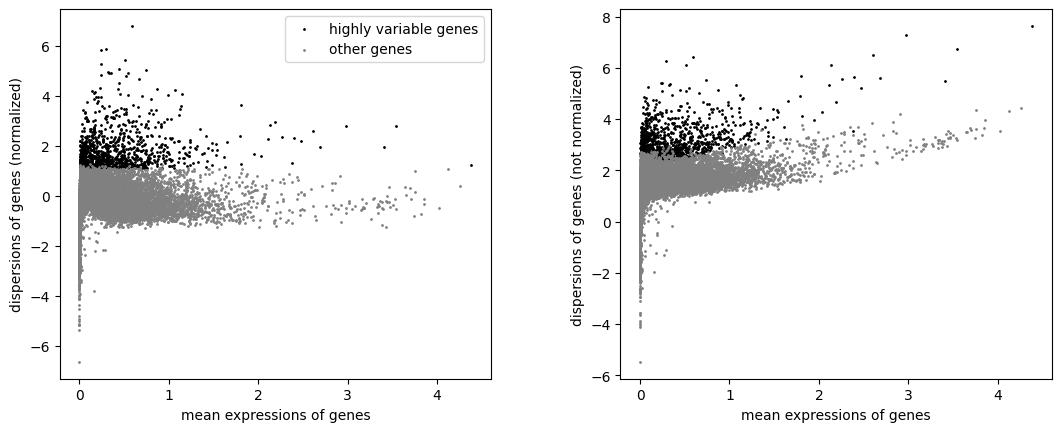

In [24]:
sc.pl.highly_variable_genes(train_combined_full)

In [25]:
# Checking if PTPRC is present in the training data
PTPRC_ENS = "ENSG00000081237"

if PTPRC_ENS not in train_combined_full.var_names:
    print(f"PTPRC ({PTPRC_ENS}) is not in var_names — dropped during ortholog alignment")
else:
    row = train_combined_full.var.loc[PTPRC_ENS]
    print("=== PTPRC in train_combined_full.var ===")
    print(f"  highly_variable       : {row['highly_variable']}")
    print(f"  highly_variable_nbatches: {row['highly_variable_nbatches']}")
    print(f"  highly_variable_intersection: {row['highly_variable_intersection']}")
    print(f"  means                 : {row['means']:.4f}")
    print(f"  dispersions           : {row['dispersions']:.4f}")
    print(f"  dispersions_norm      : {row['dispersions_norm']:.4f}")

    import numpy as np
    X = train_combined_full[:, PTPRC_ENS].X
    X = X.toarray().ravel() if hasattr(X, "toarray") else np.asarray(X).ravel()

    for name, mask in [("mouse", train_combined_full.obs["species"] == "mouse"),
                       ("human", train_combined_full.obs["species"] == "human")]:
        xs = X[mask.values]
        print(f"\n  {name}: mean={xs.mean():.3f}  "
              f"var={xs.var():.3f}  "
              f"frac_nonzero={100*(xs>0).mean():.1f}%  "
              f"max={xs.max():.3f}")

    full_ranked = train_combined_full.var.sort_values(
        ["highly_variable_nbatches", "dispersions_norm"],
        ascending=[False, False],
    )
    rank = list(full_ranked.index).index(PTPRC_ENS) + 1
    total = len(full_ranked)
    print(f"\n  overall rank (by nbatches then dispersions_norm): {rank} / {total}")

    cutoff_row = full_ranked.iloc[999]
    print(f"\n  1000th-ranked gene has:")
    print(f"    nbatches         : {cutoff_row['highly_variable_nbatches']}")
    print(f"    dispersions_norm : {cutoff_row['dispersions_norm']:.4f}")

=== PTPRC in train_combined_full.var ===
  highly_variable       : False
  highly_variable_nbatches: 0
  highly_variable_intersection: False
  means                 : 2.0673
  dispersions           : 2.8406
  dispersions_norm      : 0.0887

  mouse: mean=1.037  var=1.218  frac_nonzero=58.6%  max=4.702

  human: mean=1.677  var=1.786  frac_nonzero=69.1%  max=6.252

  overall rank (by nbatches then dispersions_norm): 5349 / 14451

  1000th-ranked gene has:
    nbatches         : 1
    dispersions_norm : 1.1095


In [26]:
import scanpy as sc

mouse_only = train_combined_full[train_combined_full.obs["species"] == "mouse"].copy()
human_only = train_combined_full[train_combined_full.obs["species"] == "human"].copy()

sc.pp.highly_variable_genes(mouse_only, n_top_genes=1000, flavor="seurat")
sc.pp.highly_variable_genes(human_only, n_top_genes=1000, flavor="seurat")

PTPRC = "ENSG00000081237"
LAST_HVG = "ENSG00000111481"

for gene, label in [(PTPRC, "PTPRC"), (LAST_HVG, "last HVG")]:
    print(f"\n=== {label} ({gene}) ===")
    for name, a in [("mouse", mouse_only), ("human", human_only)]:
        if gene not in a.var.index:
            print(f"  {name}: not in var")
            continue
        row = a.var.loc[gene]
        print(f"  {name}: "
              f"mean={row['means']:.3f}  "
              f"disp={row['dispersions']:.3f}  "
              f"disp_norm={row['dispersions_norm']:.3f}  "
              f"HVG={row['highly_variable']}")


=== PTPRC (ENSG00000081237) ===
  mouse: mean=1.704  disp=2.660  disp_norm=0.274  HVG=False
  human: mean=2.430  disp=3.022  disp_norm=-0.097  HVG=False

=== last HVG (ENSG00000111481) ===
  mouse: mean=1.249  disp=2.180  disp_norm=-0.052  HVG=False
  human: mean=0.555  disp=3.186  disp_norm=2.271  HVG=True


## 6. UMAP comparison: PTPRC vs top HVGs

**Comparison A** — UMAP in the full 14k ortholog space. Both the top 10 HVGs and
PTPRC are present, so we can compare them on the same coordinate system.
PTPRC (CD45, `ENSG00000081237`) is a pan-leukocyte marker that is highly expressed
but not highly *variable*, so HVG selection drops it. This comparison reveals
whether PTPRC drives cluster structure or is uniformly expressed.

In [27]:
adata_14k = train_combined_full.copy()

# normalize_total +log1p, values are between 0 and 8.8
# However, between genes, the values are not comparable
# PCA is susceptible to this
# That is why we subtract the mean the divide by the standard deviation
# There are still a couple of outliers, so we clip at max_value=10

# use_rep="X_pca" uses the PCA that we just computed
sc.pp.scale(adata_14k, max_value=10)
sc.tl.pca(adata_14k, n_comps=50, random_state=42)
sc.pp.neighbors(adata_14k, n_neighbors=15, use_rep="X_pca", random_state=42)
sc.tl.umap(adata_14k, min_dist=0.3, random_state=42)

top10_hvgs = hvg_selected.index[:10].tolist()
genes_to_show = top10_hvgs + [PTPRC_ID]
titles = [f"{g} (HVG #{i+1})" for i, g in enumerate(top10_hvgs)] + ["PTPRC (not in HVGs)"]

sc.pl.umap(
    adata_14k,
    color=genes_to_show + ["cell_type"],
    use_raw=False,
    ncols=3, frameon=False, s=10,
    title=titles + ["cell type"],
)
plt.tight_layout()
plt.show()

/n/sw/Miniforge3-24.7.1-0/lib/python3.12/functools.py:907: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


NameError: name 'hvg_selected' is not defined

**Comparison B** — UMAP in the 1000-HVG space. This is the feature space the
downstream OT model actually operates in. PTPRC is absent here (not in the top
1000 HVGs), so we visualize only the top 10 HVGs plus cell type.

/n/sw/Miniforge3-24.7.1-0/lib/python3.12/functools.py:907: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


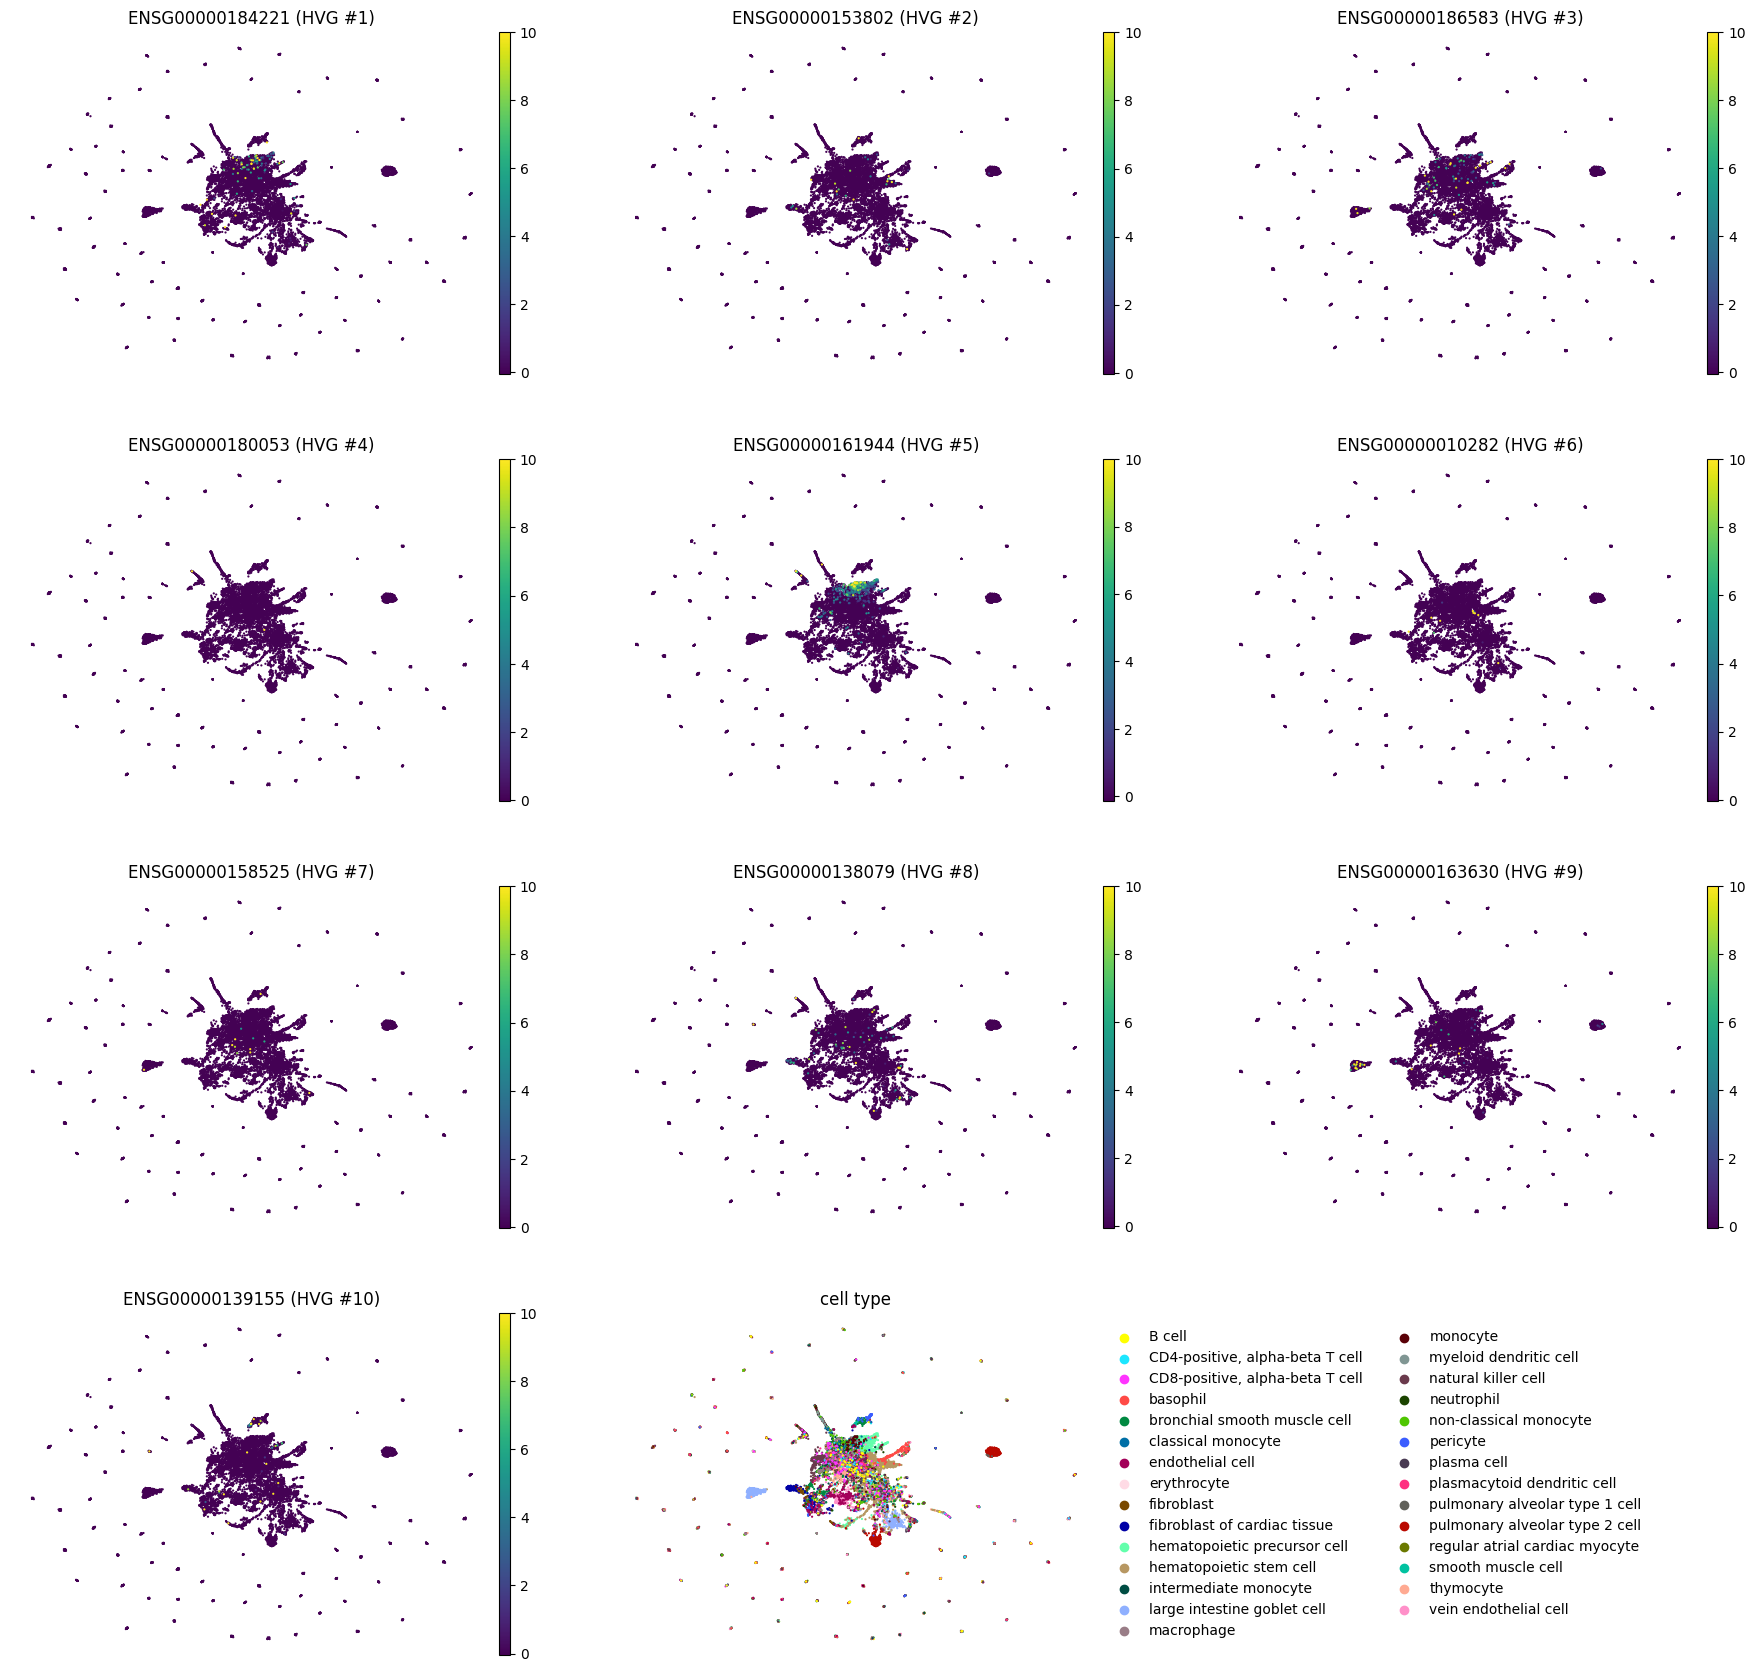

<Figure size 640x480 with 0 Axes>

In [ ]:
adata_hvg = train_combined_full[:, hvg_selected.index].copy()

sc.pp.scale(adata_hvg, max_value=10)
sc.tl.pca(adata_hvg, n_comps=50, random_state=42)
sc.pp.neighbors(adata_hvg, n_neighbors=15, use_rep="X_pca", random_state=42)
sc.tl.umap(adata_hvg, min_dist=0.3, random_state=42)

sc.pl.umap(
    adata_hvg,
    color=[*hvg_selected.index[:10].tolist(), "cell_type"],
    use_raw=False,
    ncols=3, frameon=False, s=10,
    title=[f"{g} (HVG #{i+1})" for i, g in enumerate(hvg_selected.index[:10])]
          + ["cell type"],
)
plt.tight_layout()
plt.show()

## 7. Quantifying HVG quality: silhouette scores

Compare how well cell types cluster in the 14k-gene PCA space vs the 1000-HVG PCA
space. A higher silhouette score means tighter, better-separated cell-type clusters.
If HVG selection is working well, the 1000-gene space should achieve comparable or
higher silhouette scores than the full 14k space (less noise, same signal).

In [ ]:
from sklearn.metrics import silhouette_score

labels = adata_14k.obs["cell_type"].values

sil_14k = silhouette_score(adata_14k.obsm["X_pca"], labels, sample_size=5000, random_state=42)

sil_hvg = silhouette_score(adata_hvg.obsm["X_pca"], labels, sample_size=5000, random_state=42)

print("Silhouette scores (cell-type clusters in PCA space)")
print(f"  Full 14k ortholog genes:  {sil_14k:.4f}")
print(f"  Top 1000 HVGs:            {sil_hvg:.4f}")
print()
if sil_hvg >= sil_14k:
    print(f"HVG selection improved clustering (+{sil_hvg - sil_14k:.4f}). "
          "The 1000 HVGs retain the cell-type signal while reducing noise.")
else:
    print(f"HVG selection reduced clustering ({sil_hvg - sil_14k:.4f}). "
          "Some cell-type signal may have been lost in gene selection.")

Silhouette scores (cell-type clusters in PCA space)
  Full 14k ortholog genes:  -0.1674
  Top 1000 HVGs:            -0.1674

HVG selection improved clustering (+0.0000). The 1000 HVGs retain the cell-type signal while reducing noise.
